## Conversion of driver data into csv file pulling from Ergast and FastF1 API

Extracts and converts the following data into csv file:
- Driver name
- Avg finishing position
- Track specific performance (how good the driver was on this circuit compared to usual level)
- Qualifying average (Typical position driver starts in)
- Race pace deltas (How far driver is relative to the optimal pace)
- Pit Stop Time 
- Consistency (Lap Variance)
- DNFs (Did Not Finish)
- Driver strengths (tyre) 



1. Set Up 

In [12]:
# Import required libraries
import requests          # For making HTTP requests to Ergast API
import pandas as pd      # For data manipulation and CSV export
import numpy as np       # For numerical operations
import fastf1            # For F1 telemetry and lap data
import warnings          # To suppress warning messages
import logging           # To control log output
from datetime import datetime  # For timestamping exports
import os                # For creating directories

# Suppress warnings for cleaner output
warnings.filterwarnings('ignore')

# Suppress FastF1 info logs (only show warnings and errors)
logging.getLogger('fastf1').setLevel(logging.WARNING)

# Create cache directory if it doesn't exist
cache_dir = 'f1_cache'
if not os.path.exists(cache_dir):
    os.makedirs(cache_dir)

# Enable FastF1 cache (stores downloaded data locally to speed up future runs)
fastf1.Cache.enable_cache(cache_dir)

print("✓ All libraries imported successfully!")
print(f"✓ FastF1 cache enabled at './{cache_dir}'")
print("✓ Ready to collect F1 data!")

✓ All libraries imported successfully!
✓ FastF1 cache enabled at './f1_cache'
✓ Ready to collect F1 data!


### 2. Data Extraction

2.1 Load Helper Data

In [2]:
import sys
import os

# Add car_data to path
car_data_path = os.path.abspath('../car_data')
sys.path.insert(0, car_data_path)

# Import the helper dictionaries
from driver_to_number import driver_to_number
from driver_to_team import driver_to_team

print("✓ Helper functions imported!")
print(f"✓ {len(driver_to_number)} driver numbers loaded")
print(f"✓ {len(driver_to_team)} driver-team mappings loaded")

✓ Helper functions imported!
✓ 22 driver numbers loaded
✓ 21 driver-team mappings loaded


2.2 Get 2024 Race Schedule

In [ ]:
# python
import fastf1

# Get 2024 schedule (exclude testing)
sched = fastf1.get_event_schedule(2024)
races_df = sched[sched['EventFormat'] != 'testing'][['RoundNumber', 'EventName']]
print(races_df)            # quick view
race_list = list(races_df.itertuples(index=False, name=None))  

req         WARNING 	DEFAULT CACHE ENABLED! (3.41 GB) /Users/teanlee/Library/Caches/fastf1


    RoundNumber                  EventName
1             1         Bahrain Grand Prix
2             2   Saudi Arabian Grand Prix
3             3      Australian Grand Prix
4             4        Japanese Grand Prix
5             5         Chinese Grand Prix
6             6           Miami Grand Prix
7             7  Emilia Romagna Grand Prix
8             8          Monaco Grand Prix
9             9        Canadian Grand Prix
10           10         Spanish Grand Prix
11           11        Austrian Grand Prix
12           12         British Grand Prix
13           13       Hungarian Grand Prix
14           14         Belgian Grand Prix
15           15           Dutch Grand Prix
16           16         Italian Grand Prix
17           17      Azerbaijan Grand Prix
18           18       Singapore Grand Prix
19           19   United States Grand Prix
20           20     Mexico City Grand Prix
21           21       São Paulo Grand Prix
22           22       Las Vegas Grand Prix
23         

2.3 Define Helper Functions for Data Collection

In [10]:
# Helper functions (one cell)
import pandas as pd
import numpy as np

def get_finish_position(session, driver_code):
    """Extract finishing position and DNF status."""
    res = session.results
    row = res[res['Abbreviation'] == driver_code]
    if row.empty:
        return {'Finish_Position': None, 'DNF': None, 'DNF_Reason': None}
    row = row.iloc[0]
    dnf = 0 if str(row['Status']).lower() == 'finished' else 1
    return {
        'Finish_Position': int(row['Position']) if pd.notna(row['Position']) else None,
        'DNF': dnf,
        'DNF_Reason': row['Status'] if dnf == 1 else None
    }

def get_qualifying_position(quali_session, driver_code):
    """Extract qualifying position."""
    try:
        res = quali_session.results
        row = res[res['Abbreviation'] == driver_code]
        return {'Quali_Position': int(row.iloc[0]['Position'])} if not row.empty else {'Quali_Position': None}
    except:
        return {'Quali_Position': None}

def get_lap_metrics(session, driver_code):
    """Extract lap consistency and race pace delta."""
    try:
        laps = session.laps.pick_driver(driver_code)
        # Filter clean laps (no pit in/out)
        clean = laps[(laps['LapTime'].notna()) & (laps['PitInTime'].isna()) & (laps['PitOutTime'].isna())]
        
        if len(clean) == 0:
            return {'Avg_Lap_Time': None, 'Lap_Variance': None, 'Race_Pace_Delta': None}
        
        lap_times = clean['LapTime'].dt.total_seconds()
        avg_lap = lap_times.mean()
        variance = lap_times.std()
        
        # Compare to fastest lap in race
        try:
            fastest = session.laps['LapTime'].min().total_seconds()
            pace_delta = avg_lap - fastest
        except:
            pace_delta = None
        
        return {
            'Avg_Lap_Time': avg_lap,
            'Lap_Variance': variance,
            'Race_Pace_Delta': pace_delta
        }
    except Exception as e:
        # Laps not loaded or driver not found
        return {'Avg_Lap_Time': None, 'Lap_Variance': None, 'Race_Pace_Delta': None}

def get_pit_stop_metrics(session, driver_code):
    """Extract pit stop count and average duration."""
    try:
        laps = session.laps.pick_driver(driver_code)
        pits = laps[laps['PitOutTime'].notna()]
        
        if len(pits) == 0:
            return {'Num_Pit_Stops': 0, 'Avg_Pit_Stop_Time': None}
        
        durations = []
        for _, pit in pits.iterrows():
            if pd.notna(pit['PitInTime']) and pd.notna(pit['PitOutTime']):
                dur = (pit['PitOutTime'] - pit['PitInTime']).total_seconds()
                durations.append(dur)
        
        return {
            'Num_Pit_Stops': len(pits),
            'Avg_Pit_Stop_Time': np.mean(durations) if durations else None
        }
    except Exception:
        return {'Num_Pit_Stops': 0, 'Avg_Pit_Stop_Time': None}

def get_tyre_usage(session, driver_code):
    """Extract tyre compounds used."""
    try:
        laps = session.laps.pick_driver(driver_code)
        compounds = laps['Compound'].dropna().unique()
        return {'Tyres_Used': ','.join(compounds.astype(str)) if len(compounds) > 0 else None}
    except Exception:
        return {'Tyres_Used': None}

print("✓ Helper functions defined!")

✓ Helper functions defined!


2.4 Define Circuit Types

In [21]:
# Circuit type mapping (use FULL event names from FastF1)
CIRCUIT_TYPES = {
    'Bahrain Grand Prix': 'Permanent',
    'Saudi Arabian Grand Prix': 'Street',
    'Australian Grand Prix': 'Street',
    'Japanese Grand Prix': 'Permanent',
    'Chinese Grand Prix': 'Permanent',
    'Miami Grand Prix': 'Street',
    'Emilia Romagna Grand Prix': 'Permanent',
    'Monaco Grand Prix': 'Street',
    'Canadian Grand Prix': 'Street',
    'Spanish Grand Prix': 'Permanent',
    'Austrian Grand Prix': 'Permanent',
    'British Grand Prix': 'Permanent',
    'Hungarian Grand Prix': 'Permanent',
    'Belgian Grand Prix': 'Permanent',
    'Dutch Grand Prix': 'Permanent',
    'Italian Grand Prix': 'Permanent',
    'Azerbaijan Grand Prix': 'Street',
    'Singapore Grand Prix': 'Street',
    'United States Grand Prix': 'Permanent',
    'Mexico City Grand Prix': 'Permanent',
    'São Paulo Grand Prix': 'Permanent',
    'Las Vegas Grand Prix': 'Street',
    'Qatar Grand Prix': 'Permanent',
    'Abu Dhabi Grand Prix': 'Permanent'
}

print(f"✓ Circuit types defined for {len(CIRCUIT_TYPES)} tracks")

✓ Circuit types defined for 24 tracks


### 3. Main Data Collection and Aggregation

In [22]:
# Main extraction loop
import gc

all_rows = []
drivers = list(driver_to_team.keys())  # All 2024 drivers

print("="*70)
print(f"COLLECTING 2024 F1 SEASON DATA")
print("="*70)
print(f"Drivers: {len(drivers)}")
print(f"Races: {len(race_list)}")
print("="*70)

for idx, (rnd, race_name) in enumerate(race_list, 1):
    print(f"\n[{idx}/{len(race_list)}] {race_name}")
    
    try:
        # Load race and qualifying sessions
        race = fastf1.get_session(2024, rnd, 'R')
        race.load()
        
        # Check if laps loaded
        if race.laps is None or len(race.laps) == 0:
            print(f"  ⚠ No lap data available, skipping...")
            continue
            
        quali = fastf1.get_session(2024, rnd, 'Q')
        quali.load()
    except Exception as e:
        print(f"  ✗ Failed to load: {e}")
        continue
    
    # Extract data for each driver
    for driver in drivers:
        # Metadata
        row = {
            'Season': 2024,
            'Driver': driver,
            'Round': rnd,
            'Race_Name': race_name,
            'Circuit_Type': CIRCUIT_TYPES.get(race_name, 'Unknown'),
            'Team': driver_to_team.get(driver, 'Unknown'),
            'Car_Number': driver_to_number.get(driver)
        }
        
        # Call all helper functions and merge results
        row.update(get_finish_position(race, driver))
        row.update(get_qualifying_position(quali, driver))
        row.update(get_lap_metrics(race, driver))
        row.update(get_pit_stop_metrics(race, driver))
        row.update(get_tyre_usage(race, driver))
        
        all_rows.append(row)
        print(f"  ✓ {driver}", end=' ')
    
    # Free memory
    del race, quali
    gc.collect()
    print()

print("\n" + "="*70)
print(f"✓ DATA COLLECTION COMPLETE!")
print(f"✓ Total records: {len(all_rows)}")
print("="*70)

COLLECTING 2024 F1 SEASON DATA
Drivers: 21
Races: 24

[1/24] Bahrain Grand Prix


core           INFO 	Loading data for Bahrain Grand Prix - Race [v3.7.0]
req            INFO 	Using cached data for session_info
req            INFO 	Using cached data for driver_info
req            INFO 	Using cached data for session_status_data
req            INFO 	Using cached data for lap_count
req            INFO 	Using cached data for track_status_data
req            INFO 	Using cached data for _extended_timing_data
req            INFO 	Using cached data for timing_app_data
core           INFO 	Processing timing data...
req            INFO 	Using cached data for car_data
req            INFO 	Using cached data for position_data
req            INFO 	Using cached data for weather_data
req            INFO 	Using cached data for race_control_messages
core           INFO 	Finished loading data for 20 drivers: ['1', '11', '55', '16', '63', '4', '44', '81', '14', '18', '24', '20', '3', '22', '23', '27', '31', '10', '77', '2']
core           INFO 	Loading data for Bahrain Grand Prix - Qua

  ✓ VER   ✓ PER   ✓ HAM   ✓ RUS   ✓ LEC   ✓ SAI   ✓ NOR   ✓ PIA   ✓ ALO   ✓ STR   ✓ OCO   ✓ GAS   ✓ ALB   ✓ SAR   ✓ BOT   ✓ ZHO   ✓ MAG   ✓ HUL   ✓ TSU   ✓ RIC   ✓ BOR 

[2/24] Saudi Arabian Grand Prix


req            INFO 	Using cached data for car_data
req            INFO 	Using cached data for position_data
req            INFO 	Using cached data for weather_data
req            INFO 	Using cached data for race_control_messages
core           INFO 	Finished loading data for 20 drivers: ['1', '11', '16', '81', '14', '63', '38', '4', '44', '27', '23', '20', '31', '2', '22', '3', '77', '24', '18', '10']
core           INFO 	Loading data for Saudi Arabian Grand Prix - Qualifying [v3.7.0]
req            INFO 	Using cached data for session_info
req            INFO 	Using cached data for driver_info
req            INFO 	Using cached data for session_status_data
req            INFO 	Using cached data for track_status_data
req            INFO 	Using cached data for _extended_timing_data
req            INFO 	Using cached data for timing_app_data
core           INFO 	Processing timing data...
req            INFO 	Using cached data for car_data
req            INFO 	Using cached data for position

  ✓ VER   ✓ PER   ✓ HAM   ✓ RUS   ✓ LEC   ✓ SAI   ✓ NOR   ✓ PIA   ✓ ALO   ✓ STR   ✓ OCO   ✓ GAS   ✓ ALB   ✓ SAR   ✓ BOT   ✓ ZHO   ✓ MAG   ✓ HUL   ✓ TSU   ✓ RIC   ✓ BOR 

[3/24] Australian Grand Prix


...

core        WARNING 	Fixed incorrect tyre stint information for driver '43'
core        WARNING 	Fixed incorrect tyre stint information for driver '31'
req            INFO 	Using cached data for car_data
req            INFO 	Using cached data for position_data
req            INFO 	Using cached data for weather_data
req            INFO 	Using cached data for race_control_messages
core           INFO 	Finished loading data for 20 drivers: ['1', '16', '81', '63', '10', '55', '14', '24', '20', '4', '77', '44', '22', '30', '23', '27', '11', '18', '43', '31']
core           INFO 	Loading data for Qatar Grand Prix - Qualifying [v3.7.0]
req            INFO 	Using cached data for session_info
req            INFO 	Using cached data for driver_info
req            INFO 	Using cached data for session_status_data
req            INFO 	Using cached data for track_status_data
req            INFO 	Using cached data for _extended_timing_data
req            INFO 	Using cached data for timing_app_data
core

  ✓ VER   ✓ PER   ✓ HAM   ✓ RUS   ✓ LEC   ✓ SAI   ✓ NOR   ✓ PIA   ✓ ALO   ✓ STR   ✓ OCO   ✓ GAS   ✓ ALB   ✓ SAR   ✓ BOT   ✓ ZHO   ✓ MAG   ✓ HUL   ✓ TSU   ✓ RIC   ✓ BOR 

[24/24] Abu Dhabi Grand Prix


req            INFO 	Using cached data for car_data
req            INFO 	Using cached data for position_data
req            INFO 	Using cached data for weather_data
req            INFO 	Using cached data for race_control_messages
core           INFO 	Finished loading data for 20 drivers: ['4', '55', '16', '44', '63', '1', '10', '27', '14', '81', '23', '22', '24', '18', '61', '20', '30', '77', '43', '11']
core           INFO 	Loading data for Abu Dhabi Grand Prix - Qualifying [v3.7.0]
req            INFO 	Using cached data for session_info
req            INFO 	Using cached data for driver_info
req            INFO 	Using cached data for session_status_data
req            INFO 	Using cached data for track_status_data
req            INFO 	Using cached data for _extended_timing_data
req            INFO 	Using cached data for timing_app_data
core           INFO 	Processing timing data...
req            INFO 	Using cached data for car_data
req            INFO 	Using cached data for position_d

  ✓ VER   ✓ PER   ✓ HAM   ✓ RUS   ✓ LEC   ✓ SAI   ✓ NOR   ✓ PIA   ✓ ALO   ✓ STR   ✓ OCO   ✓ GAS   ✓ ALB   ✓ SAR   ✓ BOT   ✓ ZHO   ✓ MAG   ✓ HUL   ✓ TSU   ✓ RIC   ✓ BOR 

✓ DATA COLLECTION COMPLETE!
✓ Total records: 504


/Users/teanlee/anaconda3/envs/f1-project/lib/python3.11/site-packages/fastf1/core.py:3081: FutureWarning: pick_driver is deprecated and will be removed in a future release. Use pick_drivers instead.
  warnings.warn(("pick_driver is deprecated and will be removed"
/Users/teanlee/anaconda3/envs/f1-project/lib/python3.11/site-packages/fastf1/core.py:3081: FutureWarning: pick_driver is deprecated and will be removed in a future release. Use pick_drivers instead.
  warnings.warn(("pick_driver is deprecated and will be removed"
/Users/teanlee/anaconda3/envs/f1-project/lib/python3.11/site-packages/fastf1/core.py:3081: FutureWarning: pick_driver is deprecated and will be removed in a future release. Use pick_drivers instead.
  warnings.warn(("pick_driver is deprecated and will be removed"
/Users/teanlee/anaconda3/envs/f1-project/lib/python3.11/site-packages/fastf1/core.py:3081: FutureWarning: pick_driver is deprecated and will be removed in a future release. Use pick_drivers instead.
  warning

3.1 Aggregate and Calculate Metrics

In [23]:
df = pd.DataFrame(all_rows)

# Calculate track-specific performance (delta from driver's season average)
driver_avg_finish = df.groupby('Driver')['Finish_Position'].mean()
df['Track_Performance_Delta'] = df.apply(
    lambda row: row['Finish_Position'] - driver_avg_finish[row['Driver']] 
    if pd.notna(row['Finish_Position']) else None,
    axis=1
)

# Calculate season qualifying average
quali_avg = df.groupby('Driver')['Quali_Position'].mean()
print("\nQualifying Averages:")
print(quali_avg.sort_values())

print(f"\n✓ DataFrame shape: {df.shape}")
print(f"✓ Columns: {list(df.columns)}")


Qualifying Averages:
Driver
VER     2.916667
NOR     3.541667
RUS     5.166667
LEC     5.333333
PIA     5.416667
SAI     5.521739
HAM     8.500000
PER     9.250000
ALO     9.583333
TSU    11.125000
HUL    11.791667
ALB    12.583333
STR    12.833333
RIC    13.166667
GAS    13.208333
MAG    14.272727
OCO    14.391304
BOT    15.125000
SAR    17.500000
ZHO    18.000000
BOR          NaN
Name: Quali_Position, dtype: float64

✓ DataFrame shape: (504, 18)
✓ Columns: ['Season', 'Driver', 'Round', 'Race_Name', 'Circuit_Type', 'Team', 'Car_Number', 'Finish_Position', 'DNF', 'DNF_Reason', 'Quali_Position', 'Avg_Lap_Time', 'Lap_Variance', 'Race_Pace_Delta', 'Num_Pit_Stops', 'Avg_Pit_Stop_Time', 'Tyres_Used', 'Track_Performance_Delta']


4. CSV Export 

In [24]:
from datetime import datetime

# Export to CSV
output_file = f'f1_2024_driver_data_{datetime.now().strftime("%Y%m%d_%H%M%S")}.csv'
df.to_csv(output_file, index=False)

print("="*70)
print(f"✓ CSV EXPORTED: {output_file}")
print("="*70)
print(f"Rows: {len(df)}")
print(f"Columns: {len(df.columns)}")
print(f"\nFirst 3 rows:")
print(df.head(3))

✓ CSV EXPORTED: f1_2024_driver_data_20251216_180319.csv
Rows: 504
Columns: 18

First 3 rows:
   Season Driver  Round           Race_Name Circuit_Type      Team  \
0    2024    VER      1  Bahrain Grand Prix    Permanent  Red Bull   
1    2024    PER      1  Bahrain Grand Prix    Permanent  Red Bull   
2    2024    HAM      1  Bahrain Grand Prix    Permanent  Mercedes   

   Car_Number  Finish_Position  DNF DNF_Reason  Quali_Position  Avg_Lap_Time  \
0           1              1.0  0.0       None             1.0     95.685151   
1          11              2.0  0.0       None             5.0     96.115566   
2          44              7.0  0.0       None             9.0     96.620038   

   Lap_Variance  Race_Pace_Delta  Num_Pit_Stops  Avg_Pit_Stop_Time Tyres_Used  \
0      1.079794         3.077151              2                NaN  SOFT,HARD   
1      1.168257         3.507566              2                NaN  SOFT,HARD   
2      1.445565         4.012038              2               

### 5. Visualisation

5.1 Driver Performance Analysis

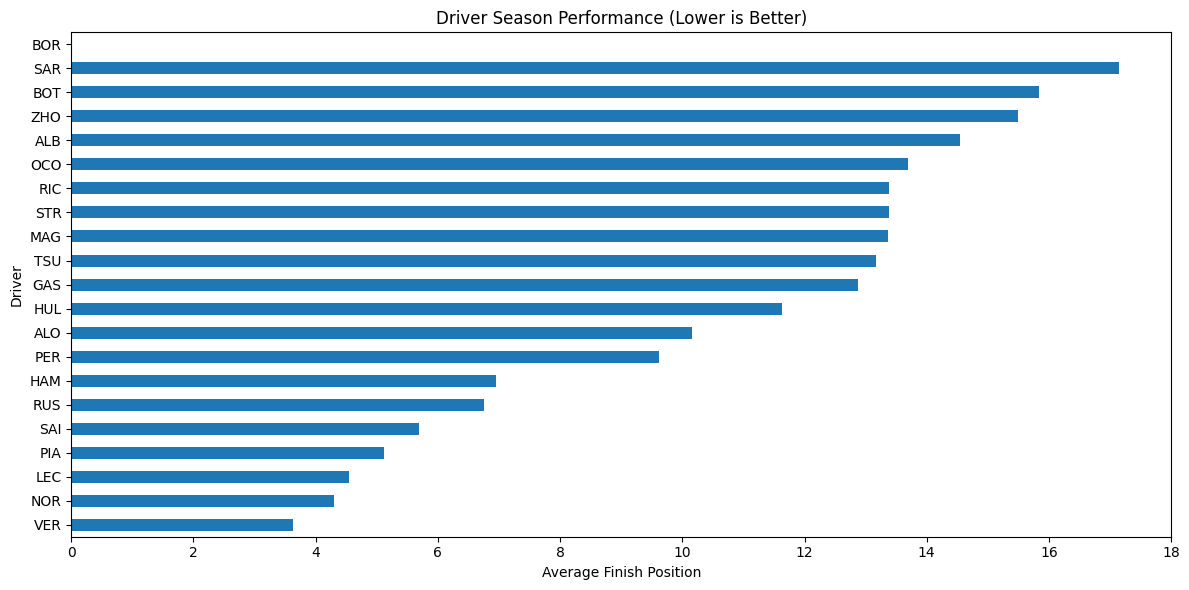

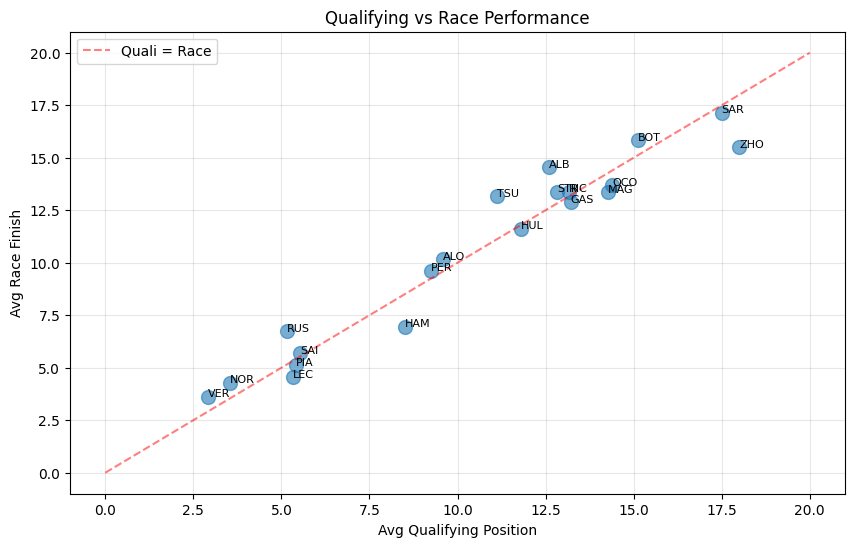

In [17]:
import matplotlib.pyplot as plt
import seaborn as sns

# Average finishing position by driver
plt.figure(figsize=(12, 6))
driver_avg_finish.sort_values().plot(kind='barh')
plt.xlabel('Average Finish Position')
plt.title('Driver Season Performance (Lower is Better)')
plt.tight_layout()
plt.show()

# Qualifying vs Race performance
fig, ax = plt.subplots(figsize=(10, 6))
quali_avg = df.groupby('Driver')['Quali_Position'].mean()
race_avg = df.groupby('Driver')['Finish_Position'].mean()
plt.scatter(quali_avg, race_avg, s=100, alpha=0.6)
for driver in quali_avg.index:
    plt.annotate(driver, (quali_avg[driver], race_avg[driver]), fontsize=8)
plt.plot([0, 20], [0, 20], 'r--', alpha=0.5, label='Quali = Race')
plt.xlabel('Avg Qualifying Position')
plt.ylabel('Avg Race Finish')
plt.title('Qualifying vs Race Performance')
plt.legend()
plt.grid(True, alpha=0.3)
plt.show()

5.2 Consistency Analysis

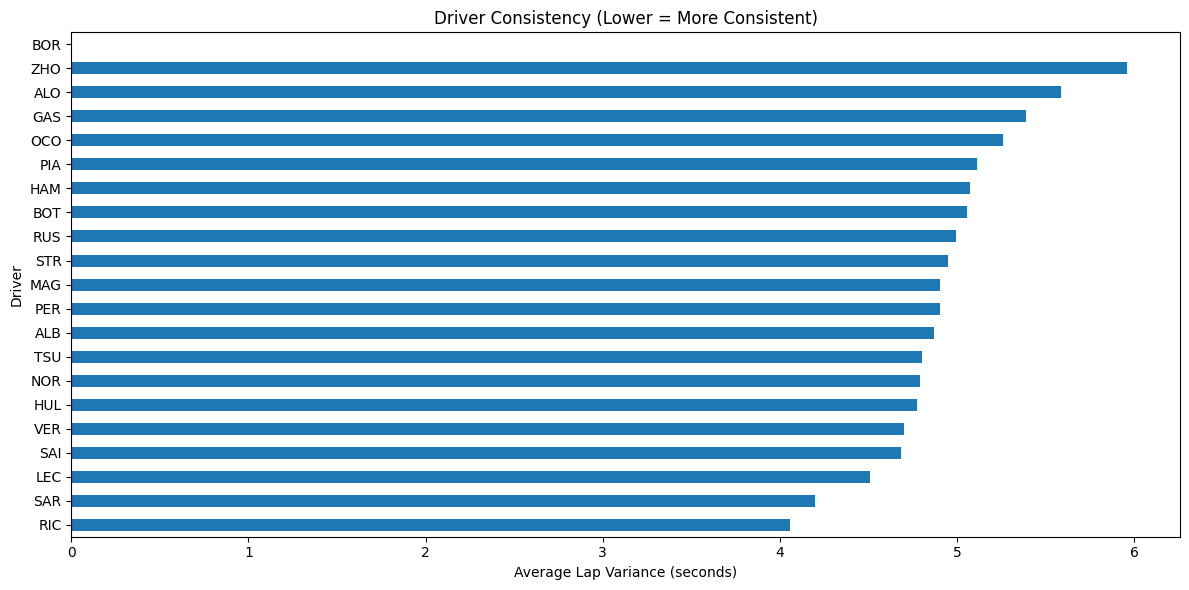

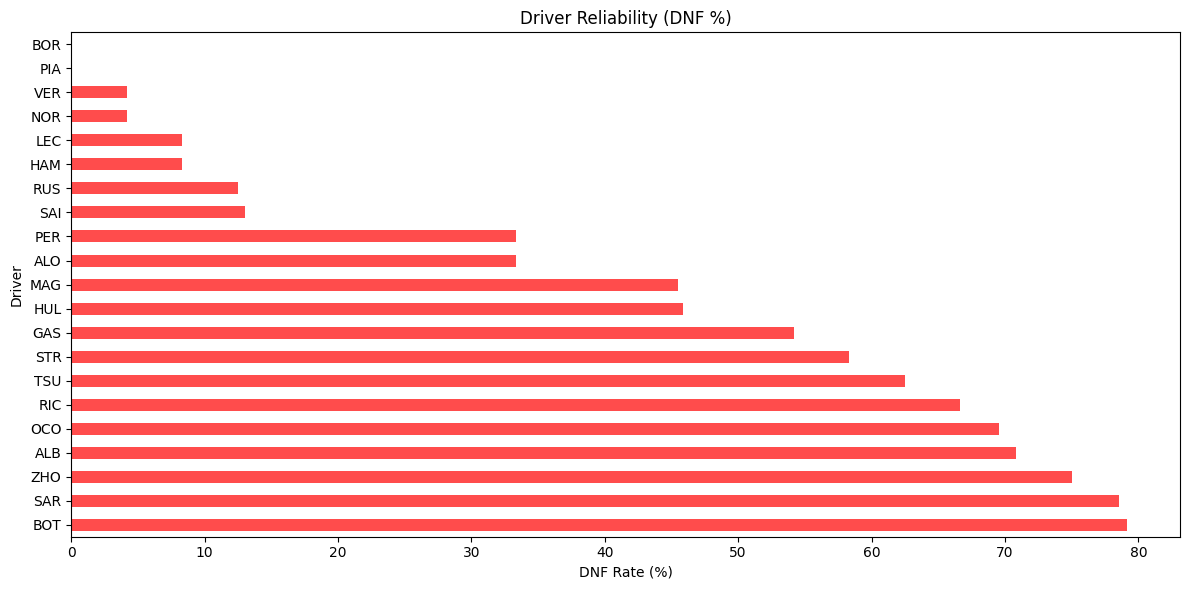

In [18]:
# Lap consistency (lower variance = more consistent)
plt.figure(figsize=(12, 6))
df.groupby('Driver')['Lap_Variance'].mean().sort_values().plot(kind='barh')
plt.xlabel('Average Lap Variance (seconds)')
plt.title('Driver Consistency (Lower = More Consistent)')
plt.tight_layout()
plt.show()

# DNF rate by driver
dnf_rate = df.groupby('Driver')['DNF'].mean() * 100
plt.figure(figsize=(12, 6))
dnf_rate.sort_values(ascending=False).plot(kind='barh', color='red', alpha=0.7)
plt.xlabel('DNF Rate (%)')
plt.title('Driver Reliability (DNF %)')
plt.tight_layout()
plt.show()

5.3 Track Performance

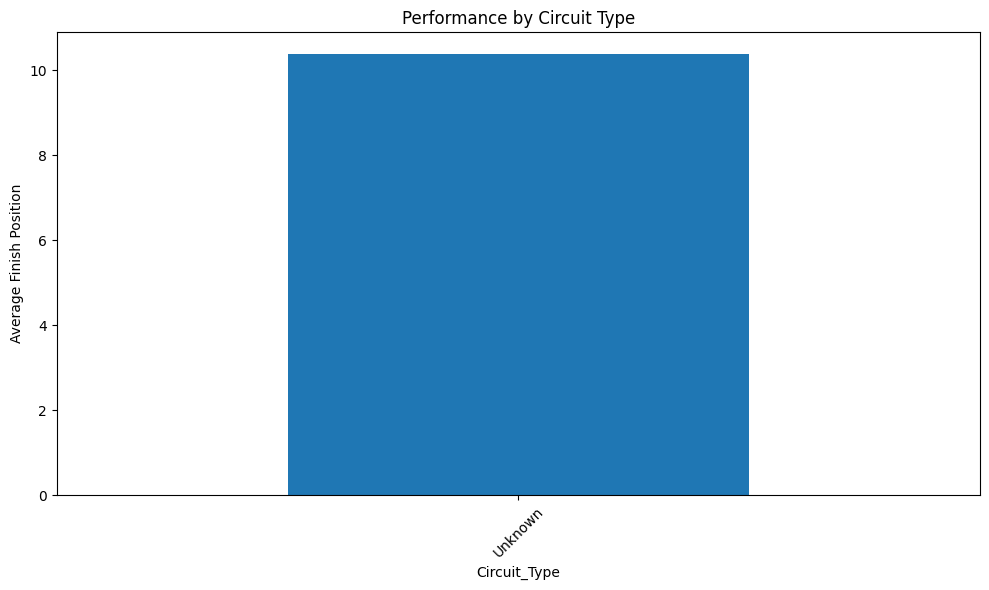

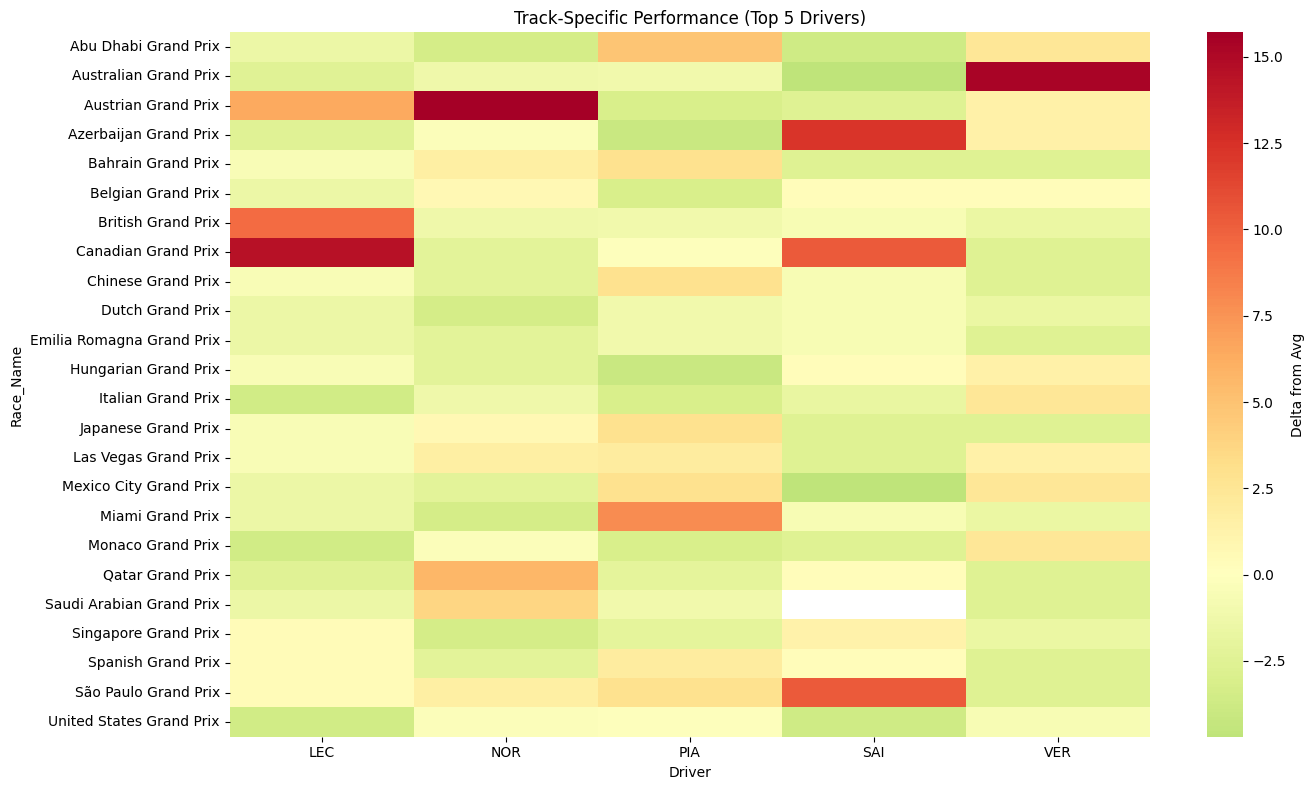

In [19]:
# Performance by circuit type
plt.figure(figsize=(10, 6))
df.groupby('Circuit_Type')['Finish_Position'].mean().plot(kind='bar')
plt.ylabel('Average Finish Position')
plt.title('Performance by Circuit Type')
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

# Track-specific performance (who overperformed/underperformed)
top_drivers = driver_avg_finish.nsmallest(5).index
track_perf = df[df['Driver'].isin(top_drivers)].pivot_table(
    values='Track_Performance_Delta', index='Race_Name', columns='Driver'
)
plt.figure(figsize=(14, 8))
sns.heatmap(track_perf, cmap='RdYlGn_r', center=0, annot=False, cbar_kws={'label': 'Delta from Avg'})
plt.title('Track-Specific Performance (Top 5 Drivers)')
plt.tight_layout()
plt.show()

5.4 Pace and Strategy

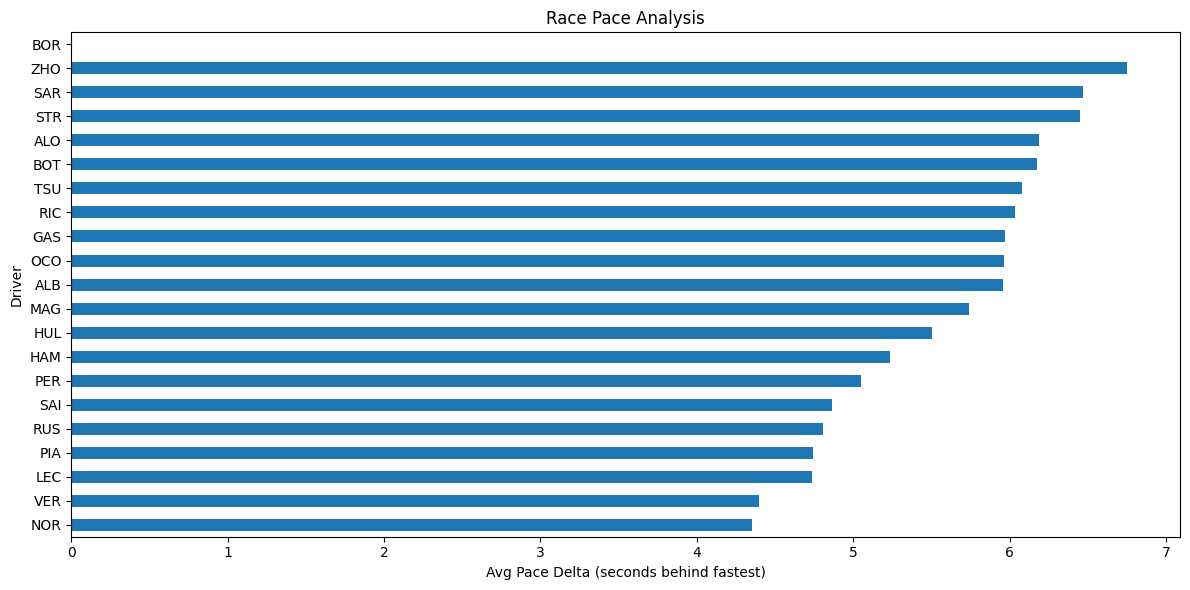

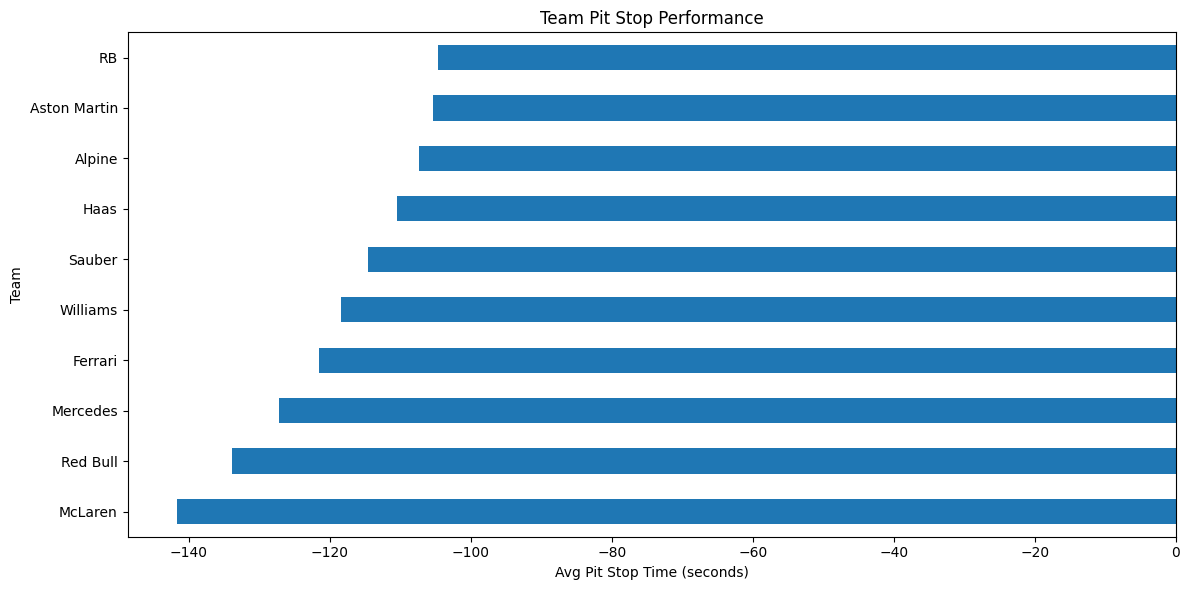

In [20]:
# Race pace delta (how far from fastest lap)
plt.figure(figsize=(12, 6))
df.groupby('Driver')['Race_Pace_Delta'].mean().sort_values().plot(kind='barh')
plt.xlabel('Avg Pace Delta (seconds behind fastest)')
plt.title('Race Pace Analysis')
plt.tight_layout()
plt.show()

# Pit stop efficiency
plt.figure(figsize=(12, 6))
df.groupby('Team')['Avg_Pit_Stop_Time'].mean().sort_values().plot(kind='barh')
plt.xlabel('Avg Pit Stop Time (seconds)')
plt.title('Team Pit Stop Performance')
plt.tight_layout()
plt.show()